<a href="https://colab.research.google.com/github/Tyrisk13/QLC240_random-generator/blob/main/Exercise_12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
#Import packages needed to run code
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
infile = 'jma_nitrate.csv'

Index(['Unnamed: 0', 'theta', 'sal', 'depth', 'nitrate', 'lon', 'lat', 'date',
       'year', 'month', 'day', 'profile', 'cruise', 'vessel', 'density'],
      dtype='object')


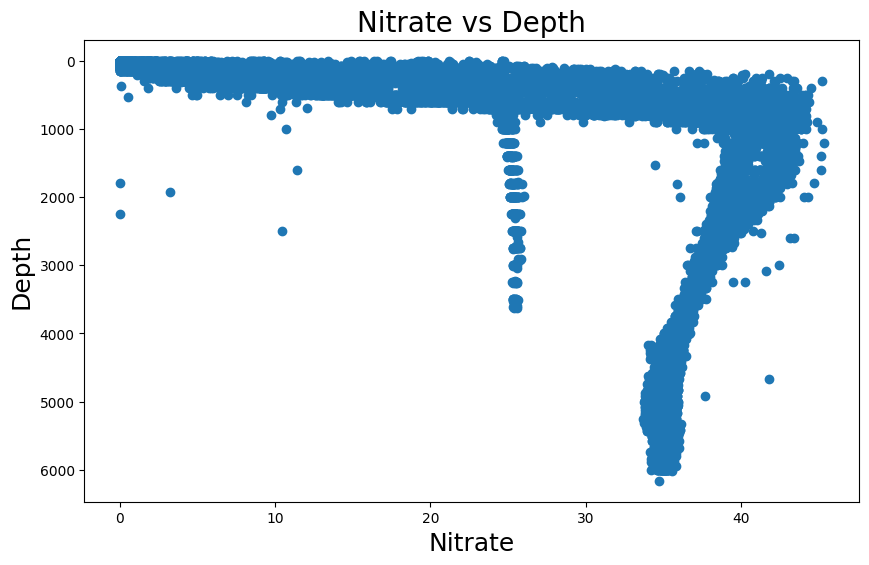

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('jma_nitrate.csv')

# Check for the correct column names
print(df.columns)  # Print the columns to inspect the actual names

# Filter out rows where nitrate values are -999
df_cleaned = df[df['nitrate'] != -999]

# Plotting the scatter plot
plt.figure(figsize=(10,6))

# Replace 'nitrate' and 'depth' with actual column names from the printed output if needed
plt.scatter(df_cleaned['nitrate'], df_cleaned['depth'])
plt.xlabel('Nitrate', fontsize=18)
plt.ylabel('Depth', fontsize=18)
plt.title('Nitrate vs Depth', fontsize=20)

# Invert the y-axis to simulate ocean depth
plt.gca().invert_yaxis()

# Show the plot
plt.show()


In [33]:
# Reading in the Argo float data with no NO3 values
infile = 'kuro_BGCargo_noNO3.csv'
data_BGC = pd.read_csv(infile, sep = (','))

# Separating the date column of BGC argo data into year month and day columns to look at seasonality compared to the jma data.
import datetime

data_BGC['year'] = pd.DatetimeIndex(data_BGC['Date/GMT']).year
data_BGC['month'] = pd.DatetimeIndex(data_BGC['Date/GMT']).month
data_BGC['day'] = pd.DatetimeIndex(data_BGC['Date/GMT']).day
#data_BGC.head()

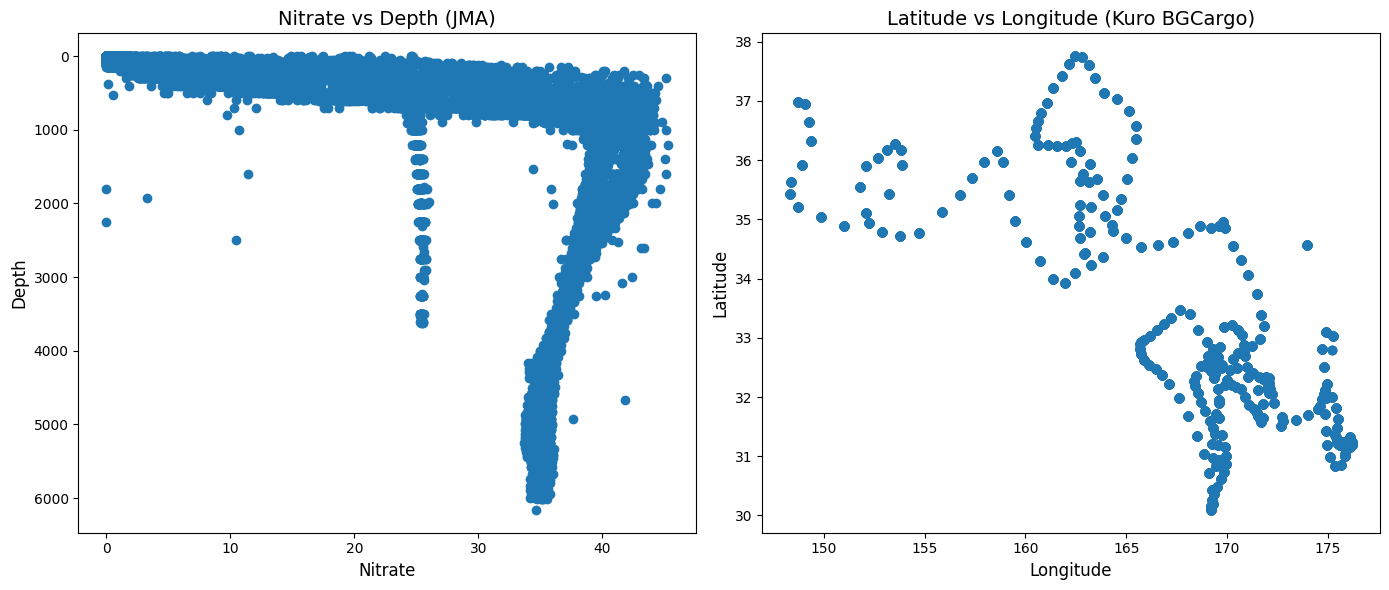

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the JMA data and filter out -999 values for nitrate
df_jma = pd.read_csv('jma_nitrate.csv')
df_jma_cleaned = df_jma[df_jma['nitrate'] != -999]

# Load the kuro_BGCargo_noNO3 data
df_kuro = pd.read_csv('kuro_BGCargo_noNO3.csv')

# Create a figure with two subplots for both datasets
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot Nitrate vs Depth from JMA data
axs[0].scatter(df_jma_cleaned['nitrate'], df_jma_cleaned['depth'])
axs[0].set_xlabel('Nitrate', fontsize=12)
axs[0].set_ylabel('Depth', fontsize=12)
axs[0].set_title('Nitrate vs Depth (JMA)', fontsize=14)
axs[0].invert_yaxis()  # Invert y-axis for depth

# Plot Latitude vs Longitude from kuro_BGCargo_noNO3 data
axs[1].scatter(df_kuro['LON'], df_kuro['LAT'])
axs[1].set_xlabel('Longitude', fontsize=12)
axs[1].set_ylabel('Latitude', fontsize=12)
axs[1].set_title('Latitude vs Longitude (Kuro BGCargo)', fontsize=14)

# Show the plots
plt.tight_layout()
plt.show()


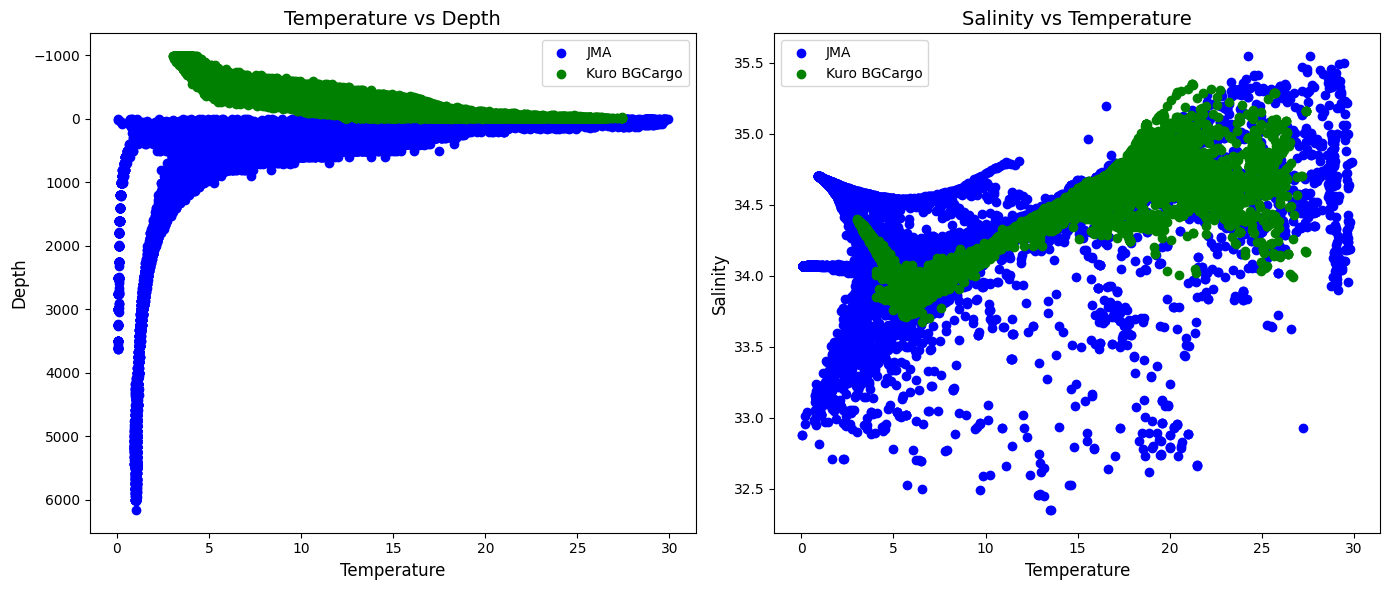

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the JMA data and filter out -999 values for nitrate
df_jma = pd.read_csv('jma_nitrate.csv')
df_jma_cleaned = df_jma[df_jma['nitrate'] != -999]

# Load the kuro_BGCargo_noNO3 data
df_kuro = pd.read_csv('kuro_BGCargo_noNO3.csv')

# Create a figure with two subplots for both scatter plots
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Plot for Temperature vs Depth (JMA data)
axs[0].scatter(df_jma_cleaned['theta'], df_jma_cleaned['depth'], label='JMA', color='blue')
axs[0].scatter(df_kuro['TEMPERATURE[C]'], df_kuro['DEPTH[M]'], label='Kuro BGCargo', color='green')
axs[0].set_xlabel('Temperature', fontsize=12)
axs[0].set_ylabel('Depth', fontsize=12)
axs[0].set_title('Temperature vs Depth', fontsize=14)
axs[0].invert_yaxis()  # Invert y-axis for depth
axs[0].legend()

# Plot for Salinity vs Temperature (JMA data)
axs[1].scatter(df_jma_cleaned['theta'], df_jma_cleaned['sal'], label='JMA', color='blue')
axs[1].scatter(df_kuro['TEMPERATURE[C]'], df_kuro['SALINITY[PSS]'], label='Kuro BGCargo', color='green')
axs[1].set_xlabel('Temperature', fontsize=12)
axs[1].set_ylabel('Salinity', fontsize=12)
axs[1].set_title('Salinity vs Temperature', fontsize=14)
axs[1].legend()

# Show the plots
plt.tight_layout()
plt.show()


In [36]:
infile = 'kuro_BGCargo_noNO3.csv'
data_BGC = pd.read_csv(infile, sep = (','))

# Separating the date column of BGC argo data into year month and day columns to look at seasonality compared to the jma data.
import datetime

data_BGC['year'] = pd.DatetimeIndex(data_BGC['Date/GMT']).year
data_BGC['month'] = pd.DatetimeIndex(data_BGC['Date/GMT']).month
data_BGC['day'] = pd.DatetimeIndex(data_BGC['Date/GMT']).day
#data_BGC.head()

In [37]:
#import the jma nitrate file, then get columns I want for training
infile = 'jma_nitrate.csv'
nitratefile = pd.read_csv(infile,sep=(','))
nitratefilefiltered = nitratefile[nitratefile.nitrate>0]
X = nitratefilefiltered[["sal","theta"]]
y = nitratefilefiltered[["nitrate"]]
print(np.shape(X))
print(np.shape(y))


#split data set to train/test 20/80 split
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

(15574, 2)
(15574, 1)


In [38]:
import matplotlib.pyplot as plt
import random


# pick model
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from math import sqrt

#run KNN with K neighbors ranging from 1-15, calculating
#r2 and RMSE to find the best fit model
results = []
for n in range(1,16,1):
    res = []
    model = KNeighborsRegressor(n_neighbors=n)
    model.fit(X_train, y_train)
    #print ('Neighbors = %s\n' % (int(n)))
    # compute the R^2 score
    accuracyscore = model.score(X_train,y_train)
    #print("Training R^2 score: {0:.2f}\n".format(model.score(X_train,y_train)))
    # plot the model together with the data
    xfit = X_test
    yfit = model.predict(xfit)
    #print("Testing R^2 score: {0:.2f}\n".format(model.score(xfit,yfit)))
    rmse = sqrt(mean_squared_error(y_test, yfit))
    #print("RMSE = %s \n" % (rmse))
    res = [n,accuracyscore,rmse]
    results.append(res)
results

[[1, 0.9999110613989356, 2.6058678198832435],
 [2, 0.9927289125889681, 2.4303135395420776],
 [3, 0.989436962483429, 2.320717656355632],
 [4, 0.9877493952444761, 2.294790385486795],
 [5, 0.9862445125445002, 2.265924014995549],
 [6, 0.9853651009567571, 2.2178185162292237],
 [7, 0.9846615070565908, 2.213675727092634],
 [8, 0.9840785865559012, 2.1952765454848047],
 [9, 0.9836823893549954, 2.20225936338761],
 [10, 0.9833161917430909, 2.1939401652725508],
 [11, 0.9830143132143836, 2.2023368473610616],
 [12, 0.98254256174158, 2.2144196381599355],
 [13, 0.9820371954017075, 2.2041353557622165],
 [14, 0.9816750176585883, 2.208859357144669],
 [15, 0.9812961480610605, 2.2152382383662066]]

In [39]:
myarray = np.asarray(results)
myarray

array([[ 1.        ,  0.99991106,  2.60586782],
       [ 2.        ,  0.99272891,  2.43031354],
       [ 3.        ,  0.98943696,  2.32071766],
       [ 4.        ,  0.9877494 ,  2.29479039],
       [ 5.        ,  0.98624451,  2.26592401],
       [ 6.        ,  0.9853651 ,  2.21781852],
       [ 7.        ,  0.98466151,  2.21367573],
       [ 8.        ,  0.98407859,  2.19527655],
       [ 9.        ,  0.98368239,  2.20225936],
       [10.        ,  0.98331619,  2.19394017],
       [11.        ,  0.98301431,  2.20233685],
       [12.        ,  0.98254256,  2.21441964],
       [13.        ,  0.9820372 ,  2.20413536],
       [14.        ,  0.98167502,  2.20885936],
       [15.        ,  0.98129615,  2.21523824]])

In [40]:
myarray = np.asarray(results)

#make a dataframe with each column named for ploting
data = pd.DataFrame({'Kneighbors': myarray[:,0], 'AccScore': myarray[:,1], 'RMSE': myarray[:,2]})
data

,Kneighbors,AccScore,RMSE
0,1.0,0.999911,2.605868
1,2.0,0.992729,2.430314
2,3.0,0.989437,2.320718
3,4.0,0.987749,2.294790
4,5.0,0.986245,2.265924
5,6.0,0.985365,2.217819
6,7.0,0.984662,2.213676
7,8.0,0.984079,2.195277
8,9.0,0.983682,2.202259
9,10.0,0.983316,2.193940


In [41]:
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X_train, y_train)
print ('Neighbors = %s\n' % (10))
    # compute the R^2 score
accuracyscore = model.score(X_train,y_train)
print("Training R^2 score: {0:.2f}\n".format(model.score(X_train,y_train)))
    # plot the model together with the data
xfit = X_test
yfit = model.predict(xfit)
print("Testing R^2 score: {0:.2f}\n".format(model.score(xfit,yfit)))
rmse = sqrt(mean_squared_error(y_test, yfit))
print("RMSE = %s \n" % (rmse))

Neighbors = 10

Training R^2 score: 0.98

Testing R^2 score: 1.00

RMSE = 2.1939401652725508 



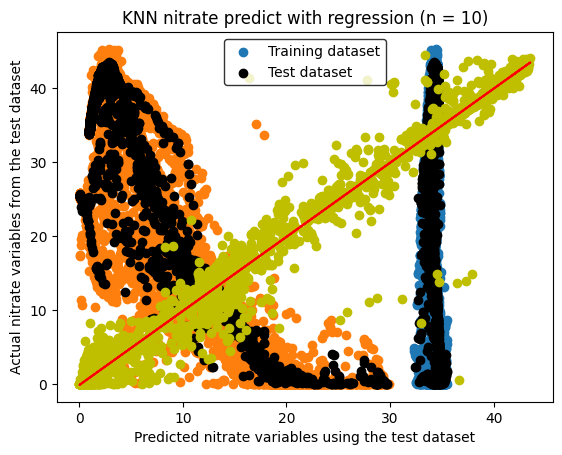

r2 = 0.999959576377461 

RMSE = 0.09684058256270314 



In [42]:
plt.scatter(X_train[["sal"]],y_train)
plt.scatter(xfit[["sal"]], yfit,c = 'k')
plt.xlabel('Salinity')
plt.ylabel('Nitrate (uM)')
plt.title('Nitrate vs Salinity, Test and Training data sets')
plt.legend(('Training dataset', 'Test dataset'), edgecolor = 'k')
#Plot temperature vs. nitrate predicted
plt.scatter(X_train[["theta"]],y_train)
plt.scatter(xfit[["theta"]], yfit,c = 'k')
plt.xlabel('Temperature (C)')
plt.ylabel('Nitrate (uM)')
plt.title('Nitrate vs Temperature, Test and Training data sets')
plt.legend(('Training dataset', 'Test dataset'), edgecolor = 'k')
#Plot predicted nitrate from test compared to actual nitrate from test
#this is using the best fit model decided above
from sklearn.linear_model import LinearRegression
plt.scatter(yfit,y_test,color = 'y')
linear_regressor = LinearRegression()  # create object for the class
linear_regressor.fit(yfit, y_test)  # perform linear regression
Y_pred = linear_regressor.predict(yfit)  # make predictions
plt.plot(yfit, Y_pred, color='red')
plt.xlabel("Predicted nitrate variables using the test dataset")
plt.ylabel("Actual nitrate variables from the test dataset")
plt.title("KNN nitrate predict with regression (n = 10)")
plt.show()
r2 = r2_score(yfit, Y_pred)
print("r2 = %s \n" % (r2))
rmse = sqrt(mean_squared_error(yfit, Y_pred))
print("RMSE = %s \n" % (rmse))
#The plot and r2/RMSE values above show that the predicted nitrate values for the test dataset compare well to the actual nitrate values. There are some outliers seen on the graph but the statistics show that the model is a great fit overall on the test dataset.


In [43]:
infilekuro = 'kuro_BGCargo_noNO3.csv'
nitratefilekuro = pd.read_csv(infilekuro,sep=(','))
X = nitratefilekuro[["SALINITY[PSS]","TEMPERATURE[C]"]]

infilekurowithnitrate = 'kuro_BGCargo_NO3.csv'
realNO3file = pd.read_csv(infilekurowithnitrate,sep=(','))
NO3real = realNO3file[["NITRATE[uMOL/KG]"]]



In [44]:
Xconcat = pd.concat([X, NO3real], axis=1)
#print Xconcat.shape
NO3filter =  Xconcat['NITRATE[uMOL/KG]']>=0
#print(NO3filter.head())
AllNo3filtered = Xconcat[NO3filter]
X = AllNo3filtered[["SALINITY[PSS]","TEMPERATURE[C]"]]
# Rename the column SALINITY[PSS] to sal
X.rename(columns={'SALINITY[PSS]': 'sal'}, inplace=True)
# Rename the column TEMPERATURE[C] to theta
X.rename(columns={'TEMPERATURE[C]': 'theta'}, inplace=True)
#print X.shape
NO3real = AllNo3filtered[["NITRATE[uMOL/KG]"]]
#print AllNo3filtered.shape
#NO3filter

<ipython-input-44-d30773ad5634>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.rename(columns={'SALINITY[PSS]': 'sal'}, inplace=True)
<ipython-input-44-d30773ad5634>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.rename(columns={'TEMPERATURE[C]': 'theta'}, inplace=True)


In [45]:
model = KNeighborsRegressor(n_neighbors=10)
model.fit(X_train, y_train)
print ('Neighbors = %s\n' % (10))
    # compute the R^2 score
accuracyscore = model.score(X_train,y_train)
print("Training R^2 score: {0:.2f}\n".format(model.score(X_train,y_train)))
    # plot the model together with the data
xfit = X_test
yfit = model.predict(xfit)
print("Testing R^2 score: {0:.2f}\n".format(model.score(xfit,yfit)))
rmse = sqrt(mean_squared_error(y_test, yfit))
print("RMSE = %s \n" % (rmse))




Neighbors = 10

Training R^2 score: 0.98

Testing R^2 score: 1.00

RMSE = 2.1939401652725508 



In [46]:
NO3predicted = model.predict(X)
NO3predicted


array([[42.054],
       [41.457],
       [41.446],
       ...,
       [40.26 ],
       [39.383],
       [38.218]])

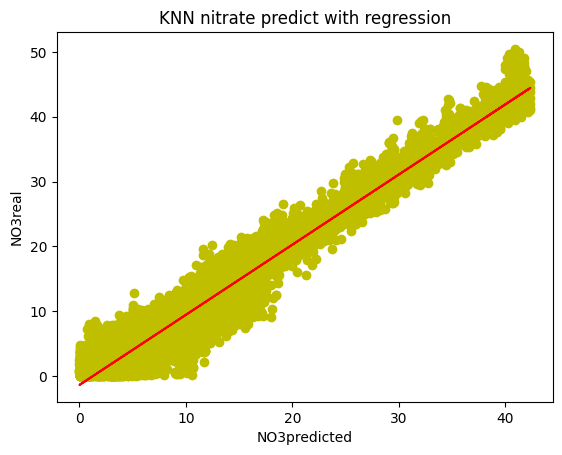

r2 = 0.9541059426388332 

RMSE = 2.562037974512438 



In [47]:
ax = plt.scatter(NO3predicted,NO3real,color = 'y')
linear_regressor = LinearRegression()  # create object for the class
linear_regressor.fit(NO3predicted, NO3real)  # perform linear regression
Y_pred = linear_regressor.predict(NO3predicted)  # make predictions
plt.plot(NO3predicted, Y_pred, color='red')
plt.xlabel("NO3predicted")
plt.ylabel("NO3real")
plt.title("KNN nitrate predict with regression")
plt.show()
r2 = r2_score(NO3predicted, NO3real)
print("r2 = %s \n" % (r2))
#text(50, 5, r2, fontsize=12)
rmse = sqrt(mean_squared_error(NO3predicted, NO3real))
print("RMSE = %s \n" % (rmse))

In [48]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

layers_saved = []
results = []
for nodes in range(7,10,1):
    for layers in range(7,10,1):
        layers_saved.append(nodes)

        mlp = MLPRegressor(hidden_layer_sizes=layers_saved,max_iter=500,random_state=4)
        mlp.fit(X_train,y_train)
        trainres = mlp.score(X_train,y_train)
        predictions = mlp.predict(X_test)
        accresults = mlp.score(X_test,y_test)
        res = [nodes,layers,trainres,accresults]
        results.append(res)
    layers_saved=[]
print(results)


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed w

[[7, 7, 0.9162687294076185, 0.9213543007174791], [7, 8, 0.9157024890919858, 0.9207134615736478], [7, 9, 0.9198097029562033, 0.9250881620892377], [8, 7, 0.8714871377146776, 0.8776441310213711], [8, 8, 0.9197392507654927, 0.9243773039688101], [8, 9, 0.9189544956150362, 0.9237015546806409], [9, 7, 0.9142692845904898, 0.918218149615439], [9, 8, 0.9146041230363336, 0.9187622669459592], [9, 9, 0.9213352586464023, 0.9263302297201945]]


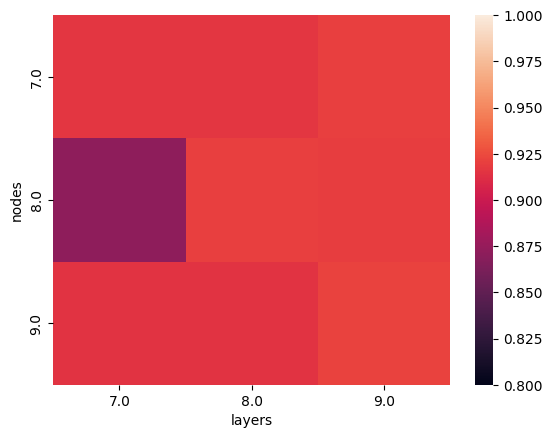

In [49]:
import seaborn as sns
myarray = np.asarray(results)

data = pd.DataFrame({'nodes': myarray[:,0], 'layers': myarray[:,1], 'Z': myarray[:,2]})
data_pivoted = data.pivot(index="nodes", columns="layers", values="Z")
ax = sns.heatmap(data_pivoted,vmin=0.8, vmax=1)
plt.show()

In [50]:
# Create mlpregrssor model with 8 nodes and 8 layers
mlp = MLPRegressor(hidden_layer_sizes=(8,8),max_iter=500,random_state=4)
mlp.fit(X_train,y_train)
trainres = mlp.score(X_train,y_train)
predictions = mlp.predict(X_test)
accresults = mlp.score(X_test,y_test)

/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:1650: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [51]:
predictions

array([41.05937746, 28.95814057, 28.12541968, ..., 14.13978849,
       40.73982516, 40.80273152])

In [52]:
accresults


0.9243773039688101

In [53]:
#Predict the y values from X using the mlp model above
NO3predicted = mlp.predict(X)
#Reshape so that it NO3predicted is 1d array
NO3predicted = NO3predicted.reshape(-1,1)
NO3predicted

array([[40.89292151],
       [40.85710114],
       [40.47737137],
       ...,
       [38.33604452],
       [37.46545578],
       [36.35262978]])

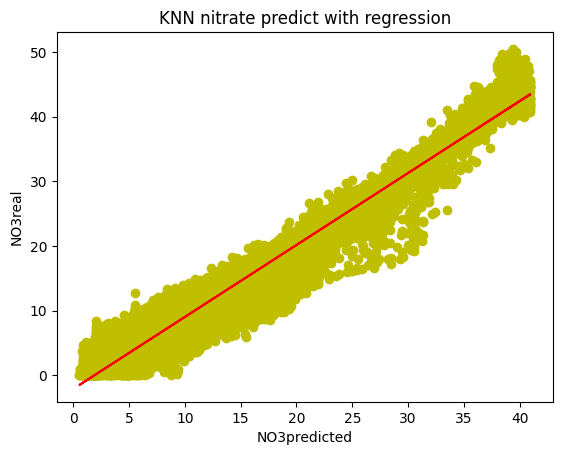

r2 = 0.941117144119898 

RMSE = 2.8221553328275886 



In [54]:
#NO3realfilter = NO3real[NO3real.NITRATE[uMOL/KG]>0]
ax = plt.scatter(NO3predicted,NO3real,color = 'y')
linear_regressor = LinearRegression()  # create object for the class
linear_regressor.fit(NO3predicted, NO3real)  # perform linear regression
Y_pred = linear_regressor.predict(NO3predicted)  # make predictions
plt.plot(NO3predicted, Y_pred, color='red')
plt.xlabel("NO3predicted")
plt.ylabel("NO3real")
plt.title("KNN nitrate predict with regression")
plt.show()
r2 = r2_score(NO3predicted, NO3real)
print("r2 = %s \n" % (r2))
#text(50, 5, r2, fontsize=12)
rmse = sqrt(mean_squared_error(NO3predicted, NO3real))
print("RMSE = %s \n" % (rmse))

An interesting thing to model in the construction industry is Site Data: this can include surveys, soil tests, weather conditions, and logistics for site suitability and safety.

Geotechnical Analysis:
	•	X-Axis: Depth below surface.
	•	Y-Axis: Soil density, moisture content, or shear strength.